## Q14 — What is the most common type of surface used in tournaments?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load
IN_DIR = "cleaned_data"

tourn = pd.read_parquet(f'{IN_DIR}/tournament.parquet')
clean = tourn.dropna(subset=['ground_type'])
print(f"{tourn['ground_type'].isna().sum()} of {len(tourn)} rows have no recorded surface -- excluded.\n")

273 of 16873 rows have no recorded surface -- excluded.



In [3]:
# tournament.parquet is one row per MATCH, not per tournament. "Most common
# surface used in tournaments" is ambiguous between:
#   (a) most matches played on X (match-level -- draw size affects this)
#   (b) most distinct tournaments held on X (tournament-level)
# tournament_unique_id is unusable (100% null, confirmed during cleaning), so
# distinct tournaments are approximated by (tournament_name, category_name).
# Sanity check first: does surface stay consistent within that grouping, as
# it should for a single real-world tournament?

g = clean.groupby(['tournament_name', 'tournament_category_name'])['ground_type'].nunique()
n_inconsistent = int((g > 1).sum())
print(f"{n_inconsistent} of {len(g)} tournament groups show more than one surface label ")
 
tourn_surface = (clean.groupby(['tournament_name', 'tournament_category_name'])['ground_type']
                  .agg(lambda x: x.mode().iloc[0]))
 
match_counts = clean['ground_type'].value_counts()
tournament_counts = tourn_surface.value_counts()
 
print("Match-level counts:\n", match_counts, "\n")
print("Tournament-level counts:\n", tournament_counts, "\n")
print(f"Most common surface: {match_counts.idxmax()}")

8 of 529 tournament groups show more than one surface label 
Match-level counts:
 ground_type
Hardcourt outdoor    8116
Red clay             5609
Hardcourt indoor     2172
Grass                 242
Red clay indoor       218
Carpet indoor         126
Synthetic outdoor      99
Green clay             18
Name: count, dtype: Int64 

Tournament-level counts:
 ground_type
Hardcourt outdoor    239
Red clay             182
Hardcourt indoor      84
Grass                  8
Red clay indoor        7
Carpet indoor          5
Synthetic outdoor      3
Green clay             1
Name: count, dtype: Int64 

Most common surface: Hardcourt outdoor


In [4]:
# Roll up into the standard broad surface families -- "type of surface" in
# tennis usually means Hard/Clay/Grass/Carpet, not the indoor/outdoor split.
family_map = {
    'Hardcourt outdoor': 'Hard', 'Hardcourt indoor': 'Hard',
    'Red clay': 'Clay', 'Red clay indoor': 'Clay', 'Green clay': 'Clay',
    'Grass': 'Grass',
    'Carpet indoor': 'Carpet',
    'Synthetic outdoor': 'Synthetic',
}
match_family = clean['ground_type'].map(family_map).value_counts()
tourn_family = tourn_surface.map(family_map).value_counts()
 
print("\nBroad surface family -- matches:\n", match_family)
print("\nBroad surface family -- tournaments:\n", tourn_family)


Broad surface family -- matches:
 ground_type
Hard         10288
Clay          5845
Grass          242
Carpet         126
Synthetic       99
Name: count, dtype: int64

Broad surface family -- tournaments:
 ground_type
Hard         323
Clay         190
Grass          8
Carpet         5
Synthetic      3
Name: count, dtype: int64


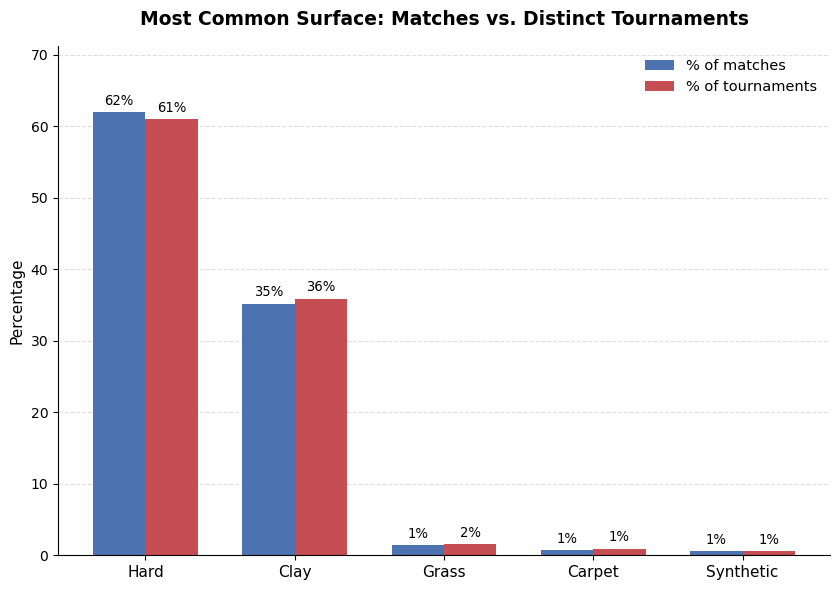

In [5]:
# Visualization: grouped bar chart, matches vs tournaments, broad families
families = match_family.index.tolist()
match_pct = (match_family / match_family.sum() * 100).reindex(families)
tourn_pct = (tourn_family / tourn_family.sum() * 100).reindex(families)
 
x = np.arange(len(families))
width = 0.35
 
fig, ax = plt.subplots(figsize=(8.5, 6))
b1 = ax.bar(x - width/2, match_pct, width, label='% of matches', color='#4C72B0')
b2 = ax.bar(x + width/2, tourn_pct, width, label='% of tournaments', color='#C44E52')
 
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%', ha='center', fontsize=9.5)
 
ax.set_xticks(x)
ax.set_xticklabels(families, fontsize=11)
ax.set_ylabel('Percentage', fontsize=11)
ax.set_title('Most Common Surface: Matches vs. Distinct Tournaments', fontsize=13.5, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10.5)
ax.set_ylim(0, max(match_pct.max(), tourn_pct.max()) * 1.15)
plt.tight_layout()
plt.savefig('charts\q14_surface_distribution.png', dpi=200, bbox_inches='tight')

Observation: Hard is first at both levels (~62% of matches, ~61% of tournaments); Clay second (~35–36%).

Interpretation: Match-level and tournament-level shares are close, so draw-size differences by surface are small in this data.

Limitation: 8 of 529 tournament groups had mixed surface labels (mode used); ranking is unchanged but the inconsistency remains.

In [7]:
tour = pd.read_parquet('cleaned_data/tournament.parquet')
venue = pd.read_parquet('cleaned_data/venue.parquet')

df = tour.merge(venue, on='match_id', how='left')

def location(gt):
    if pd.isna(gt):
        return pd.NA
    g = str(gt).lower()
    if 'indoor' in g:
        return 'indoor'
    if 'outdoor' in g or g in ('red clay', 'green clay', 'grass'):
        return 'outdoor'
    return 'unknown'

df['location'] = df['ground_type'].map(location)

# ---------------------------------------------------------------------------
# 1) Tournaments: ground_type
# ---------------------------------------------------------------------------
surf_per_tid = (
    df.dropna(subset=['ground_type'])
      .groupby('tournament_id')['ground_type']
      .nunique()
)
mixed_tid = set(surf_per_tid[surf_per_tid > 1].index)
df['tournament_has_mixed_surface'] = df['tournament_id'].isin(mixed_tid)
mixed_tour= df[df['tournament_has_mixed_surface']==True].groupby('tournament_id').size().rename('match_id_counts').reset_index()
mixed_tour


,tournament_id,match_id_counts
0,127170,18
1,127577,24
2,127813,33
3,127814,41
4,127821,16
5,127826,24
6,127838,20
7,127853,25
